In [17]:
fig_num = 7 # change this to the figure number
analysis_name = "metrics" # change this to the subfolder it should save to

from c3po.analysis.analysis import figure_directory
from pathlib import Path
fig_dir = Path(figure_directory) / f"Fig{fig_num}" /analysis_name
fig_dir.mkdir(parents=True, exist_ok=True)
fig_dir

PosixPath('/home/sambray/Documents/c3po/Figures/Fig7/metrics')

In [5]:
import zipfile
from pathlib import Path

import numpy as np


def get_npz_shapes(file_path: str | Path) -> dict[str, tuple[int, ...]]:
    """Read array shapes from an NPZ file without loading array data.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to the NPZ file.

    Returns
    -------
    dict[str, tuple[int, ...]]
        Mapping from array name to array shape.
    """
    shapes = {}

    with zipfile.ZipFile(file_path, "r") as archive:
        for filename in archive.namelist():
            if not filename.endswith(".npy"):
                continue

            with archive.open(filename) as file:
                version = np.lib.format.read_magic(file)

                if version == (1, 0):
                    shape, _, _ = np.lib.format.read_array_header_1_0(file)
                elif version == (2, 0):
                    shape, _, _ = np.lib.format.read_array_header_2_0(file)
                else:
                    shape, _, _ = np.lib.format.read_array_header_2_0(file)

            name = Path(filename).stem
            shapes[name] = shape

    return shapes



In [6]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import yaml
import matplotlib.pyplot as plt
import numpy as np

file_path = "/home/sambray/Documents/c3po/tutorial/c3po_dandi_candidate_datasets_v2.csv"
dataset_df = pd.read_csv(file_path)
metric_keys = None

metrics_list = []
for i, row in tqdm(dataset_df.iterrows(), total=dataset_df.shape[0]):
    dandiset_id = row['dandiset_id']
    dandiset_id = f"{dandiset_id:06d}"
    dandi_path = dataset_df['dandi_path'].values[0]
    model_dir = Path(f"/stelmo/sam/c3po_dandi_training_v2/{dandiset_id}")
    # break
    yaml_path = model_dir / "metrics.yaml"
    if not yaml_path.exists():
        print(f"Metrics file does not exist for {dandiset_id}")
        metrics = {k: None for k in metric_keys} if metric_keys is not None else {}
        metrics_list.append(metrics)
        continue
    metrics = yaml.safe_load(open(yaml_path, 'r'))
    # load num events
    data_path = model_dir/"embedding.npz"
    n_events = get_npz_shapes(data_path)['z'][0]
    metrics["n_events"] = n_events
    metrics["dandiset_id"] = int(dandiset_id)
    metrics_list.append(metrics)
    if metric_keys is None:
        metric_keys = list(metrics.keys())

metrics_df = pd.DataFrame(metrics_list)
metrics_df.set_index('dandiset_id', inplace=True)
dataset_df = dataset_df.join(metrics_df, how='inner', on='dandiset_id')
# dataset_df

100%|██████████| 52/52 [00:00<00:00, 314.99it/s]

Metrics file does not exist for 001417
Metrics file does not exist for 001435
Metrics file does not exist for 001676
Metrics file does not exist for 001950


(119700, 16)

(array([20.,  9.,  5.,  2.,  2.,  2.,  2.,  1.,  0.,  2.,  1.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([  2.09805531,  19.44651178,  36.79496825,  54.14342472,
         71.4918812 ,  88.84033767, 106.18879414, 123.53725061,
        140.88570709, 158.23416356, 175.58262003, 192.9310765 ,
        210.27953298, 227.62798945, 244.97644592, 262.32490239,
        279.67335886, 297.02181534, 314.37027181, 331.71872828,
        349.06718475]),
 <BarContainer object of 20 artists>)

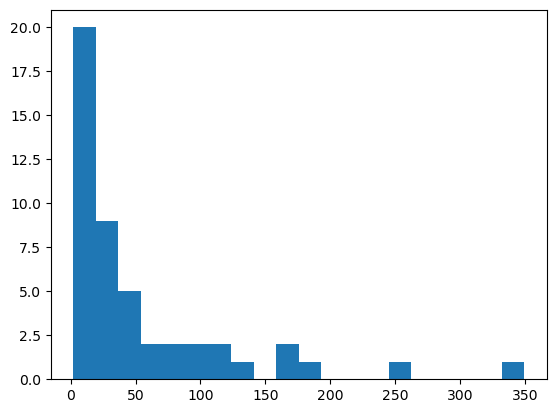

In [7]:
plt.hist(dataset_df.training_time/60, bins=20)

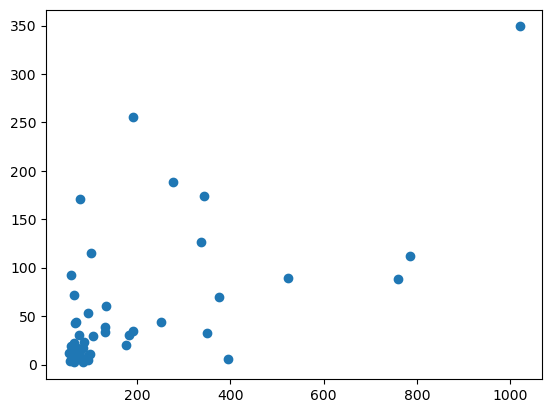

In [8]:
plt.scatter(dataset_df.n_units,dataset_df.training_time/60)
# plt.xscale('log')
# plt.yscale('log')

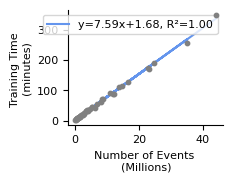

In [19]:
fig, ax = plt.subplots(figsize = (2,1.5))
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8
xx =dataset_df.n_events /1e6
yy = dataset_df.training_time/60
plt.scatter(xx,yy,c = "grey",s = 10, zorder=10)

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(xx,yy)
plt.plot(xx, slope*xx + intercept, color='cornflowerblue', label=f"y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}")
plt.xlabel("Number of Events \n(Millions)")
plt.ylabel("Training Time \n(minutes)")
plt.legend()

ax.spines[["top", "right"]].set_visible(False)
fig.savefig(fig_dir/f"training_time.svg", bbox_inches='tight', dpi=300)


In [15]:
fig_dir

PosixPath('/home/sambray/Documents/c3po/Figures/metrics')